In [4]:
## we’ll explore transfer learning by fine-tuning a MobileNetV2 model pre-trained on ImageNet for classifying MNIST digits.

# Preparing the Dataset
    # loading the MNIST dataset. Since MobileNetV2 is pre-trained on three-channel RGB images of size 224x224, 
    # we make a few adjustments to match its expected input shape:
        # Reshape the images from grayscale (28x28, 1 channel) to RGB (28x28, 3 channels).
        # Resize images to 32x32 pixels, aligning with our model’s configuration.
        # Normalize pixel values to fall between 0 and 1 by dividing by 255.

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = np.stack([train_images]*3, axis=-1) / 255.0
test_images = np.stack([test_images]*3, axis=-1) / 255.0

train_images = tf.image.resize(train_images, [32, 32])
test_images = tf.image.resize(test_images, [32, 32])

train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

In [5]:
## Building the Model
    # We load MobileNetV2 with pre-trained weights from ImageNet excluding the fully connected top layers to customize for our 10-class classification task:
        # Freeze the base model to retain learned features and avoid overfitting.
        # Add a global average pooling layer to reduce model complexity.
        # Add a dense layer with softmax activation for the output classes.

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Freeze base model

inputs = Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9652\765338436.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
# Compiling and Training the Model
    # The model is compiled with categorical cross-entropy as the loss function and accuracy as the evaluation metric. 
    # Using Adam optimizer we train the model on the MNIST training data for ten epochs.

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 50ms/step - accuracy: 0.5217 - loss: 1.5889 - val_accuracy: 0.6098 - val_loss: 1.2972
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 75s 50ms/step - accuracy: 0.6182 - loss: 1.2206 - val_accuracy: 0.6407 - val_loss: 1.1404
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 64s 43ms/step - accuracy: 0.6398 - loss: 1.1185 - val_accuracy: 0.6543 - val_loss: 1.0728
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 64s 43ms/step - accuracy: 0.6508 - loss: 1.0686 - val_accuracy: 0.6602 - val_loss: 1.0367
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 44ms/step - accuracy: 0.6563 - loss: 1.0396 - val_accuracy: 0.6652 - val_loss: 1.0145
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 55ms/step - accuracy: 0.6602 - loss: 1.0208 - val_accuracy: 0.6689 - val_loss: 0.9997
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 75s 50ms/step - accuracy: 0.6625 - loss: 1.0077 - val_accuracy: 0.6710 - val_loss: 0.9900
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 75s 50ms/step - accuracy: 0.6653 -

In [8]:
# Fine-Tuning the Model
    # After initial training we unfreeze the last few layers of the base model to perform fine-tuning. 
    # This allows the model to adjust high-level features for the MNIST data while retaining its foundational knowledge.

base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, validation_split=0.2)

Epoch 1/5



KeyboardInterrupt



In [9]:
# Model Evaluation
    # Once the model has been trained and fine-tuned we evaluate it on the test set, measuring its loss and accuracy. 
    # This step assesses how well the transfer learning model has adapted to the MNIST dataset and demonstrates its effectiveness in digit classification.
loss, accuracy = model.evaluate(test_images, test_labels)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.6669 - loss: 0.9771
Test loss: 0.9770703315734863
Test accuracy: 0.6668999791145325


313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step


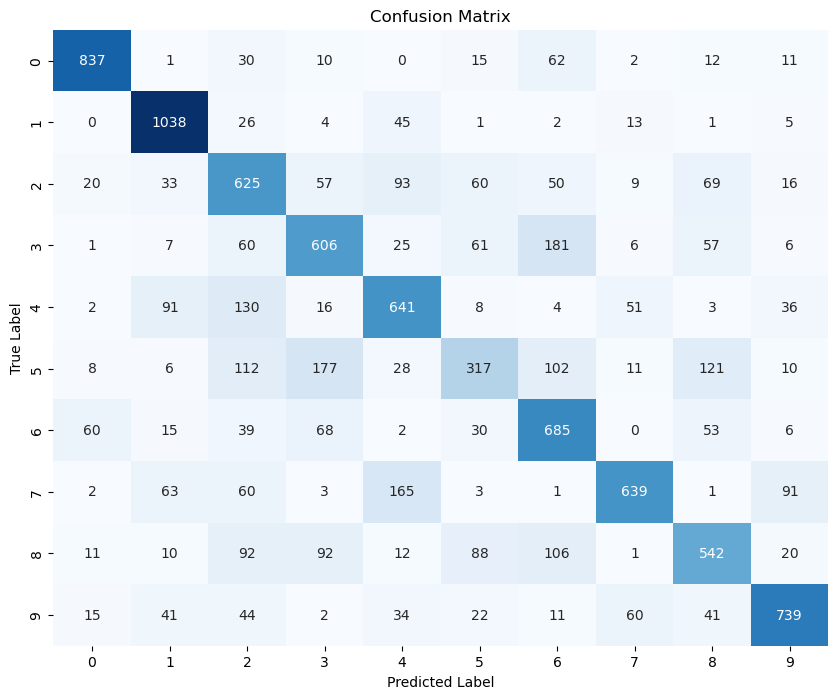

In [10]:
# Visualizing Model Performance
    # A confusion matrix provides a breakdown of correct and incorrect classifications.
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_predictions = model.predict(test_images)
test_predictions_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(test_labels, axis=1)

cm = confusion_matrix(test_true_classes, test_predictions_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

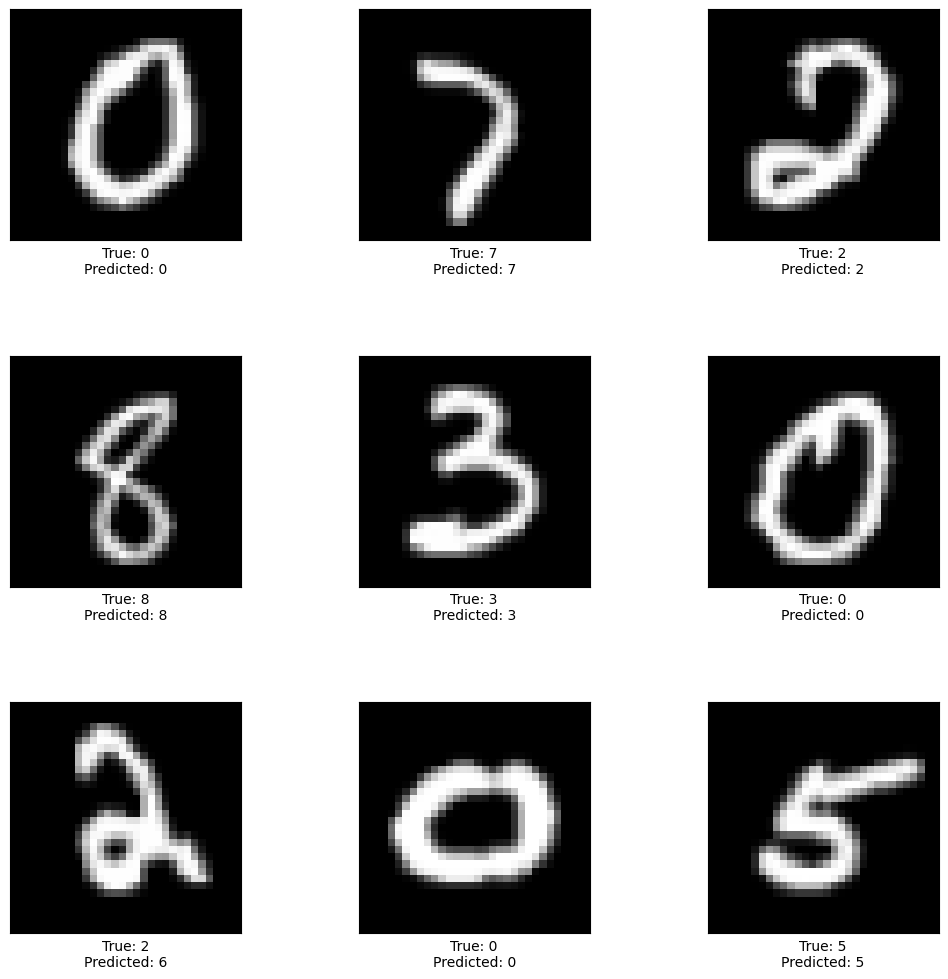

In [11]:
# Sample Image Visualization
    # Finally we select a few test images to visualize the model’s predictions against their true labels.

def display_sample(sample_images, sample_labels, sample_predictions):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)

    for i, ax in enumerate(axes.flat):
        ax.imshow(sample_images[i].reshape(32, 32), cmap='gray')
        ax.set_xlabel(f"True: {sample_labels[i]}\nPredicted: {sample_predictions[i]}")
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

test_images_gray = np.dot(test_images[...,:3], [0.2989, 0.5870, 0.1140])

random_indices = np.random.choice(len(test_images_gray), 9, replace=False)
sample_images = test_images_gray[random_indices]
sample_labels = test_true_classes[random_indices]
sample_predictions = test_predictions_classes[random_indices]
display_sample(sample_images, sample_labels, sample_predictions)


In [ ]:
## Applications of Transfer Learning
    # Transfer learning is widely used across multiple domains including:
        # Computer Vision: Transfer learning is prevalent in image recognition tasks where models pre-trained on large image datasets are adapted to specific tasks such as medical imaging, facial recognition and object detection.
        # Natural Language Processing (NLP): In NLP models like BERT, GPT or ELMo are pre-trained on vast text corpora and later fine-tuned for specific tasks such as sentiment analysis, machine translation and question-answering.
        # Healthcare: Transfer learning helps develop medical diagnostic tools using knowledge from general image recognition models to analyze medical images like X-rays or MRIs.
        # Finance: Transfer learning in finance assists in fraud detection, risk assessment and credit scoring by transferring patterns learned from related financial datasets.

## Advantages of Transfer Learning
    # Speed up the training process: By using a pre-trained model the model can learn more quickly and effectively on the second task, as it already has a good understanding of the features and patterns in the data.
    # Better performance: Transfer learning can lead to better performance on the second task, as the model can use the knowledge it has gained from the first task.
    # Handling small datasets: When there is limited data available for the second task, transfer learning can help to prevent overfitting as the model will have already learned general features that are likely to be useful in the second task.

##Disadvantages of Transfer Learning
    # Domain mismatch: The pre-trained model may not be well-suited to the second task if the two tasks are vastly different or the data distribution between the two tasks is very different.
    # Overfitting: Transfer learning can lead to overfitting if the model is fine-tuned too much on the second task, as it may learn task-specific features that do not generalize well to new data.
    # Complexity: The pre-trained model and the fine-tuning process can be computationally expensive and may require specialized hardware.